# 3 targets: SM, ET and Q

When training I will have 3 losses to optmize upon. Two of them are computed cell by cell, whilst the $ Q $ should be computed over the entire upstream basin cells. 

Now working only with 1 timeseries of discharge per basin. It is better that it comes form the outlet of the basin so that I can compute the combined loss for all the upstream cells. Otherwise some cells would be out and should not partecipate in the computation of the loss. like

loss = sm_et_q_loss (inside basin) + sm_et_loss (outside basin)

It does not make much sense. 

The other idea is to compute before hand the sampling error as we subsample the domain. So that we have a sm + et + err -> q

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import torch
import numpy as np
import xarray as xr
import pandas as pd
from pathlib import Path
import os
import random

from torch import nn

from sklearn.metrics import mean_squared_error
from hython.preprocess import reshape, apply_normalization
from hython.datasets.datasets import LSTMDataset, LSTMDischargeDataset
from hython.train_val import train_val
from hython.sampler import RegularIntervalSampler, SpaceSampler
from hython.metrics import mse_metric
from hython.losses import RMSELoss

import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import DataLoader, TensorDataset, random_split, Dataset

from hython.utils import missing_location_idx, reconstruct_from_missing, load
from hython.models.lstm import CustomLSTM



# viz
import matplotlib.pyplot as plt
from hython.viz import plot_sampler
from hython.utils import predict, prepare_for_plotting
from hython.viz import map_bias, map_pbias, map_pearson, map_at_timesteps, ts_compare, plot_sampler

def set_seed(seed):
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True

set_seed(43)

/home/iferrario/.local/miniforge/envs/emulator/lib/python3.11/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [54]:
dynamic_names = ["precip", "pet", "temp"]
static_names = [ "distance", "hao"] #, 'TT', 'KsatHorFrac'] 
target_names = [ "q_river"]


wflow_model = "talvera" # "adg1km" #"datademo" # "alps1km_eobs" # "alps1km_cerra", 

outlet_id = "1404" # adige a verona [45.44258, 11.00154]

outlet_id = "1401" # TALVERA [ 46.50977, 11.35018]


outlet_lat_lon = [ 46.50977, 11.35018]#[45.44258, 11.00154]


fn_forcings =  "forcings.nc"  # 'inmaps_eobs_eobsd_makkink_86400_2015_2019.nc' 
fn_params = "staticmaps.nc"
fn_targets = "output.nc"

fn_surr_distance = f"{wflow_model}_distance_to_outlet.nc"
fn_surr_hand = f"{wflow_model}_hand.nc"
fn_surr_hao = f"{wflow_model}_height_above_outlet.nc"

valid_start_date = "2019-01-01"
valid_end_date = "2020-12-31"

train_start_date = "2011-02-01"
train_end_date = "2018-12-31"


train_timeslice = slice(train_start_date, train_end_date)
valid_timeslice = slice(valid_start_date, valid_end_date)

In [55]:


wd = Path("/mnt/CEPH_PROJECTS/InterTwin/Wflow/models") / wflow_model


fp_d = "/mnt/CEPH_PROJECTS/InterTwin/hydrologic_data/ADO/ADO_discharge.csv"
fp_meta = "/mnt/CEPH_PROJECTS/InterTwin/hydrologic_data/ADO/ADO_Adige_surrogate_test_discharge_metadata.csv"

input_dir_path = Path('/mnt/CEPH_PROJECTS/InterTwin/Wflow/models') / wflow_model
output_dir_path = Path('/mnt/CEPH_PROJECTS/InterTwin/surrogate/')
model_weigths_path = output_dir_path / "model_weights"
surrogate_input_path = Path("/mnt/CEPH_PROJECTS/InterTwin/hydrologic_data/surrogate_inputs")

fp_surr_distance = surrogate_input_path / fn_surr_distance 
fp_surr_hand = surrogate_input_path / fn_surr_hand 
fp_surr_hao = surrogate_input_path / fn_surr_hao

fp_discharge_outlets = input_dir_path / "run_default/output.csv"

In [56]:
ado_dis = pd.read_csv(fp_d)
ado_meta = pd.read_csv(fp_meta)

In [57]:
ado_meta

,id_station,id,geom,country,region,location_site,lat,lon,start_date,end_date,...,height_dem,catchm_area,source_id,note_influence,geometry,index_wflow,basid,outlet_lat,outlet_lon,basin
0,ADO_DSC_ITH1_0038,1401,0101000020E610000039CE12094BB326400954BD044041...,Italy,Provincia Autonoma di Bolzano/Bozen,Talfer - Bozen,46.509766,11.350182,2011-01-18,2022-05-26,...,290.2515,NaN,NaN,NaN,POINT (11.35018185 46.50976619),15,10,45.44,11.0,Adige
1,ADO_DSC_ITH3_0002,1404,0101000020E61000004BAAD7A9C9002640101D867FA6B8...,Italy,Veneto,Adige a Verona,45.442581,11.001539,2010-01-01,2021-07-31,...,58.2245,NaN,NaN,NaN,POINT (11.00153857 45.44258112),15,10,45.44,11.0,Adige
2,ADO_DSC_ITH1_0034,1397,0101000020E6100000A1FA413C964B25400F9315681C5B...,Italy,Provincia Autonoma di Bolzano/Bozen,Saldurbach - Matsch,46.711804,10.647631,2009-06-01,2021-07-21,...,1649.5944,NaN,NaN,NaN,POINT (10.64763058 46.7118044),15,10,45.44,11.0,Adige


In [58]:
Q = ado_dis[ado_dis.id_station == ado_meta.set_index("id").loc[int(outlet_id)].id_station]
Q['date'] = pd.to_datetime(Q.date)
Q = Q.sort_values("date")
Q.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4164 entries, 7440520 to 7444683
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   id_station      4164 non-null   object        
 1   date            4164 non-null   datetime64[ns]
 2   discharge_m3_s  4147 non-null   float64       
 3   quality         4164 non-null   object        
dtypes: datetime64[ns](1), float64(1), object(2)
memory usage: 162.7+ KB


/tmp/ipykernel_109240/2089033209.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Q['date'] = pd.to_datetime(Q.date)


In [59]:
Q = Q.reset_index().drop(["id_station", "quality","index"], axis =1).rename({"discharge_m3_s":"discharge","date":"time"}, axis=1)

<AxesSubplot: xlabel='time'>

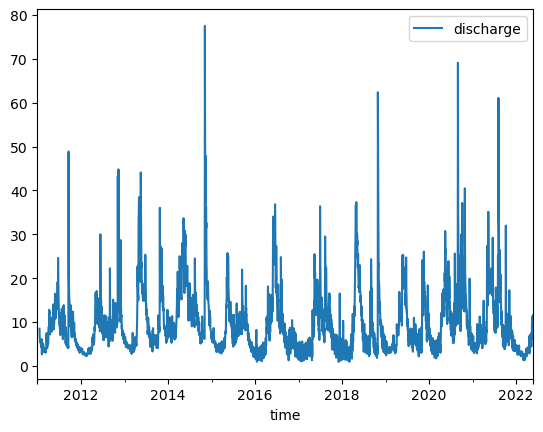

In [60]:
Q.plot(x="time")

In [61]:
forcings = xr.open_dataset(input_dir_path / fn_forcings , chunks= {"time":100})
params = xr.open_dataset(input_dir_path / fn_params ,  chunks= {"time":100}).sel(layer=1)
targets = xr.open_dataset(input_dir_path / "run_default" / fn_targets, chunks= {"time":100}).sel(layer=1).isel(lat=slice(None, None, -1))

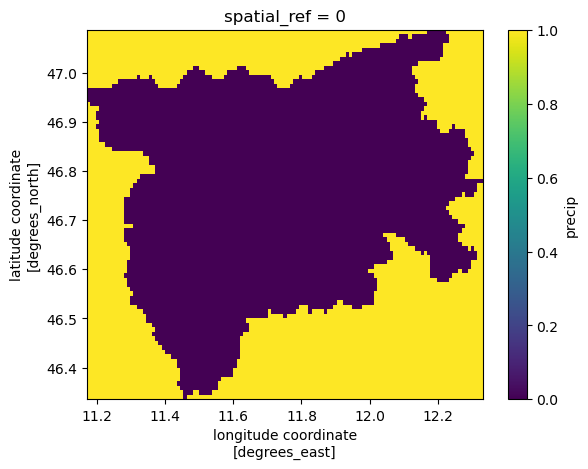

In [62]:
forcings.isnull().any("time").precip.plot()

In [63]:
try:
    forcings = forcings.rename({"latitude":"lat", "longitude":"lon"})
    params = params.rename({"latitude":"lat", "longitude":"lon"})
except:
    pass

In [64]:
hand = xr.open_dataset(fp_surr_hand).rename({"band_data":"hand"})

In [65]:
distance = xr.open_dataset(fp_surr_distance)

In [66]:
hao = xr.open_dataset(fp_surr_hao).rename({"band_data":"hao"})

In [67]:
params["distance"]= (("lat", "lon"), distance.distance.data)

In [68]:
params["hand"]= (("lat", "lon"), hand.hand.data)

In [69]:
params["hao"]= (("lat", "lon"), hao.hao.data)

In [70]:
forcings = forcings[dynamic_names]
params = params[static_names]
targets = targets[target_names] 

In [71]:
#params["distance"] = (1/(params.distance + 1))

In [72]:
# select discharge 
discharge = pd.read_csv(fp_discharge_outlets).filter(regex=f"Q_{outlet_id}|time", axis=1)
discharge['time'] = pd.to_datetime(discharge.time)

In [378]:
# training 

spatial_batch_size = 128
temporal_sampling_size = 200
seq_length = 360 # days

# model 

hidden_size = 24

model_params={
    "input_size": 3, #number of dynamic predictors - user_input
    "hidden_size": hidden_size, # user_input
    "output_size": len(target_names), # number_target - user_input
    "number_static_predictors": len(static_names), #number of static parameters - user_input 

}

## The used device for training
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [379]:
remove_lakes = False

if remove_lakes:
    mask_lakes = (targets.mean(dim = "time")[target_names[0]] == 0).astype(np.bool_)
    targets = targets.where(~mask_lakes, np.nan)
    forcings = forcings.where(~mask_lakes, np.nan)
    params = params.where(~mask_lakes, np.nan)


if train_timeslice:
    train_forcings = forcings.sel(time=train_timeslice)
    train_targets = targets.sel(time=train_timeslice)
    
    train_discharge  = discharge.loc[(discharge.time >= train_start_date) & (discharge.time <= train_end_date)]
    train_ado_discharge = Q.loc[(Q.time >= train_start_date) & (Q.time <= train_end_date)]

    valid_forcings = forcings.sel(time=valid_timeslice)
    valid_targets = targets.sel(time=valid_timeslice)
    
    valid_discharge  = discharge.loc[(discharge.time >= valid_start_date) & (discharge.time <= valid_end_date)]
    valid_ado_discharge = Q.loc[(Q.time >= valid_start_date) & (Q.time <= valid_end_date)]

<AxesSubplot: xlabel='time'>

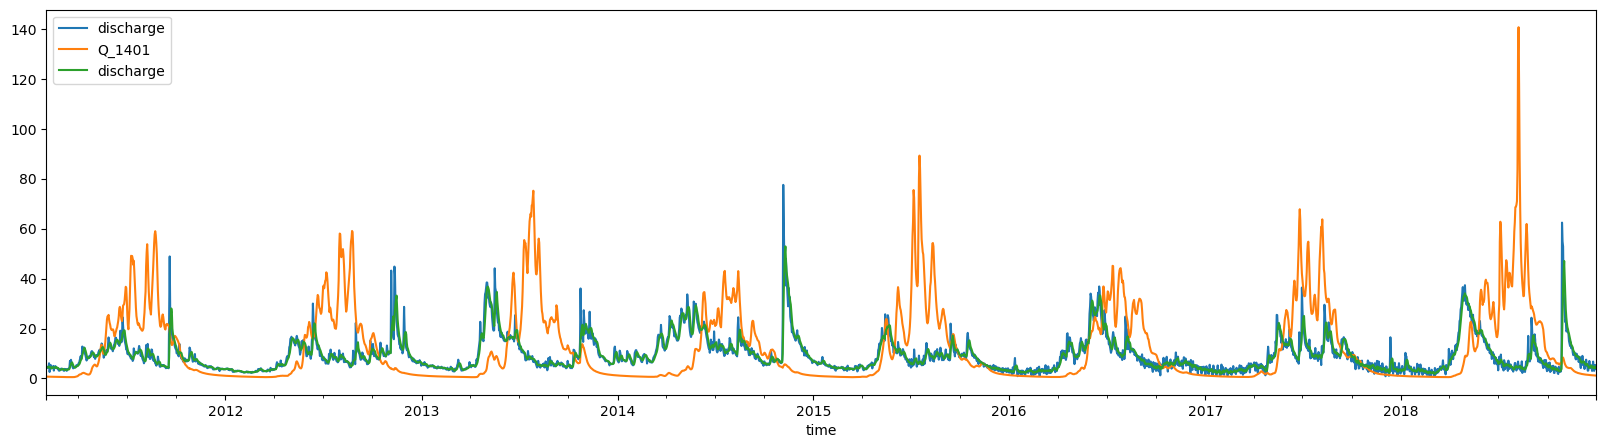

In [380]:
fig,ax = plt.subplots(1,1, figsize=(20,5))
train_ado_discharge.plot(x="time", ax=ax)
train_discharge.plot(x="time",ax=ax, label="wflow")
train_ado_discharge.set_index("time").rolling("5D").mean().plot(ax=ax, label="smooth")

<AxesSubplot: xlabel='time'>

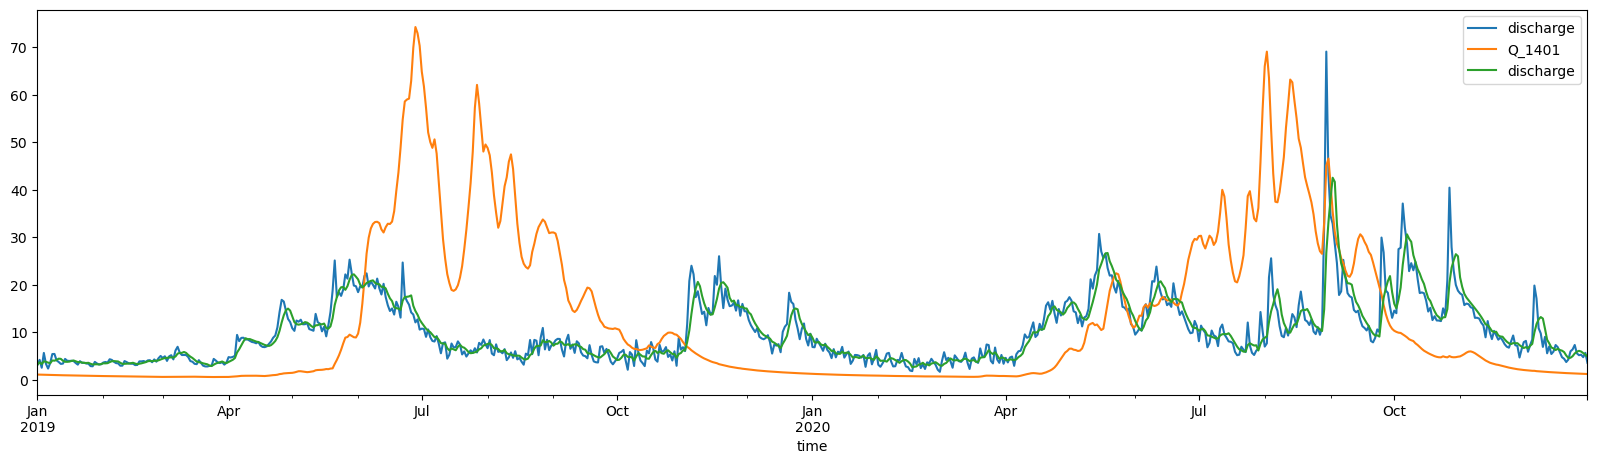

In [381]:
fig,ax = plt.subplots(1,1, figsize=(20,5))
valid_ado_discharge.plot(x="time", ax=ax)
valid_discharge.plot(x="time",ax=ax, label="wflow")
valid_ado_discharge.set_index("time").rolling("5D").mean().plot(ax=ax, label="smooth")

dynamic:  (10414, 2891, 3)  => (GRIDCELL, TIME, FEATURE)
static:  (10414, 3)  => (GRIDCELL, FEATURE)
target:  (10414, 2891, 1)  => (GRIDCELL, TIME, TARGET)
dynamic:  (10414, 731, 3)  => (GRIDCELL, TIME, FEATURE)
static:  (10414, 3)  => (GRIDCELL, FEATURE)
target:  (10414, 731, 1)  => (GRIDCELL, TIME, TARGET)


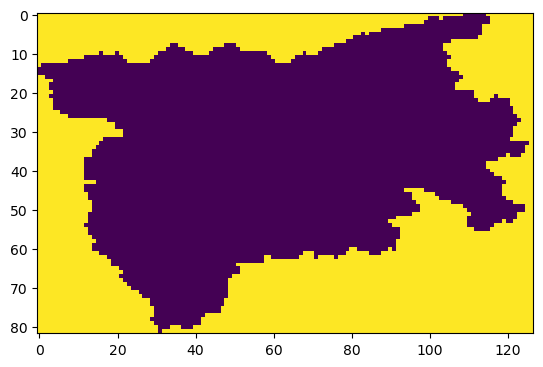

In [382]:
# UNCOMMENT IF NOT LOADING PREPROCESSED INPUTS

#reshape for training

Xd, Xs, Y  = reshape(
                   train_forcings, 
                   params, 
                   train_targets
                   )

#Define the 2D missing values mask. Sampling 

missing_mask = np.isnan(params["distance"]).values | np.isnan(params["hao"]).values | np.isnan(forcings["pet"].isel(time=0)).values

plt.imshow(missing_mask)

# UNCOMMENT TO SAVE
# np.savez_compressed( surrogate_input_path / f"{wflow_model}", Xd=Xd, Xs=Xs, Y=Y, missing_mask = missing_mask)

Xd_valid, Xs_valid, Y_valid  = reshape(
                   valid_forcings, 
                   params, 
                   valid_targets
                   )



In [345]:
Y = train_discharge[f"Q_{outlet_id}"].values

In [383]:
Y = train_ado_discharge["discharge"].values
Y = train_ado_discharge.set_index("time").rolling("5D").mean().discharge.values

In [384]:
ymean = Y.mean()
ystd = Y.std()

In [385]:
Y = np.expand_dims(Y,(0,2))# batch, time, feat

In [386]:
Y = (Y - ymean)/ ystd

In [219]:
Y_valid =  valid_discharge[f"Q_{outlet_id}"].values

In [387]:
Y_valid =  valid_ado_discharge.set_index("time").rolling("5D").mean().discharge.values

In [388]:
Y_valid = (Y_valid - ymean)/ ystd

In [389]:
Y_valid= np.expand_dims(Y_valid,(0,2))# batch, time, feat

In [390]:
Y_valid.shape

(1, 731, 1)

In [391]:
intervals = (2, 2) # every n km
train_origin = (0, 0)
val_origin = (1, 1)

spatial_train_sampler = RegularIntervalSampler(intervals = intervals, origin = train_origin)
spatial_val_sampler = RegularIntervalSampler(intervals = intervals, origin = val_origin) 

In [392]:
data2d  = forcings.to_dataarray().transpose("lat","lon", "time", "variable")

sampler_train_meta = spatial_train_sampler.sampling_idx(data2d, missing_mask)
sampler_val_meta = spatial_val_sampler.sampling_idx(data2d, missing_mask)

In [393]:
# _, d_m, d_std = apply_normalization(Xd, type = "spacetime", how ='standard')
# _, s_m, s_std = apply_normalization(Xs, type = "space", how ='standard')

In [394]:
_, d_m, d_std = apply_normalization(Xd[sampler_train_meta.idx_sampled_1d_nomissing], type = "spacetime", how ='standard')
_, s_m, s_std = apply_normalization(Xs[sampler_train_meta.idx_sampled_1d_nomissing], type = "space", how ='standard')
#_, y_m, y_std = apply_normalization(Y[sampler_train_meta.idx_sampled_1d_nomissing], type = "spacetime", how ='standard')

In [395]:
Xd = apply_normalization(Xd, type="spacetime", how="standard", m1 = d_m, m2 = d_std)
Xs = apply_normalization(Xs, type="space", how="standard",  m1 = s_m, m2 = s_std)
#Y = apply_normalization(Y, type="spacetime",how="standard", m1 = y_m, m2 = y_std)

In [396]:
Xd_valid = apply_normalization(Xd_valid, type="spacetime", how="standard", m1 = d_m, m2 = d_std)

In [397]:
Xd_valid = torch.Tensor(Xd_valid)

In [398]:
Y_valid = torch.Tensor(Y_valid)

In [399]:
Xs = torch.Tensor(Xs)
Xd = torch.Tensor(Xd)
Y = torch.Tensor(Y)

Xs.shape, Xd.shape, Y.shape

(torch.Size([10414, 3]),
 torch.Size([10414, 2891, 3]),
 torch.Size([1, 2891, 1]))

In [400]:
np.isnan(Xs[sampler_train_meta.idx_sampled_1d_nomissing]).any(), np.isnan(Xd[sampler_train_meta.idx_sampled_1d_nomissing]).any()

(tensor(0, dtype=torch.uint8), tensor(0, dtype=torch.uint8))

In [401]:
# init datasets
dataset = LSTMDischargeDataset(Xd,Y,Xs)

In [402]:
train_sampler = SpaceSampler(dataset, num_samples=100, sampling_indices = sampler_train_meta.idx_sampled_1d_nomissing.tolist())
valid_sampler = SpaceSampler(dataset, num_samples=100, sampling_indices = sampler_val_meta.idx_sampled_1d_nomissing.tolist())

In [403]:
train_loader = DataLoader(dataset, batch_size=spatial_batch_size, shuffle=False, sampler = train_sampler) # implement shuffling in the sampler!
val_loader = DataLoader(dataset, batch_size=spatial_batch_size, shuffle=False, sampler = valid_sampler)

In [404]:
model = CustomLSTM(model_params)
model = model.to(device)
model

CustomLSTM(
  (fc0): Linear(in_features=6, out_features=24, bias=True)
  (lstm): LSTM(24, 24, batch_first=True)
  (fc1): Linear(in_features=24, out_features=1, bias=True)
)

In [405]:
path2models= "./checkpoints" 
if not os.path.exists(path2models):
    os.mkdir(path2models)
    
    
opt = optim.Adam(model.parameters(), lr=1e-2)


loss_fn = RMSELoss()

metric_fn = mse_metric

lr_scheduler = ReduceLROnPlateau(opt, mode='min',factor=0.5, patience=10)

epochs = 90

params_train={
    "num_epochs": epochs,
    "temporal_sampling_idx_change_with_epoch": True,
    "temporal_sampling_size": temporal_sampling_size,
    "seq_length": seq_length,
    "ts_range": Y.shape[1],
    "optimizer": opt,
    "loss_func": loss_fn,
    "metric_func": metric_fn,
    "train_dl": train_loader, 
    "val_dl": val_loader,
    "lr_scheduler": lr_scheduler,
    "path2weights": f"{path2models}/weights.pt",
    "device":device,
    "target_names": target_names

}

In [406]:
model, sm_loss_history, sm_metric_history = train_val(model, params_train)

Epoch 0/89, current lr=0.01
Copied best model weights!
train loss: 0.9127210378646851, train metric: {'q_river': 0.6172898}
val loss: 0.8615939021110535, val metric: {'q_river': 0.5541344}
----------
Epoch 1/89, current lr=0.01
Copied best model weights!
train loss: 0.864826500415802, train metric: {'q_river': 0.67149884}
val loss: 0.8481119275093079, val metric: {'q_river': 0.6903286}
----------
Epoch 2/89, current lr=0.01
Copied best model weights!
train loss: 0.7105260491371155, train metric: {'q_river': 0.42296672}
val loss: 0.7097142338752747, val metric: {'q_river': 0.41074765}
----------
Epoch 3/89, current lr=0.01
Copied best model weights!
train loss: 0.7085094451904297, train metric: {'q_river': 0.4297523}
val loss: 0.6819660663604736, val metric: {'q_river': 0.37642497}
----------
Epoch 4/89, current lr=0.01
train loss: 0.7459280490875244, train metric: {'q_river': 0.5691505}
val loss: 0.7039889097213745, val metric: {'q_river': 0.46654776}
----------
Epoch 5/89, current lr=

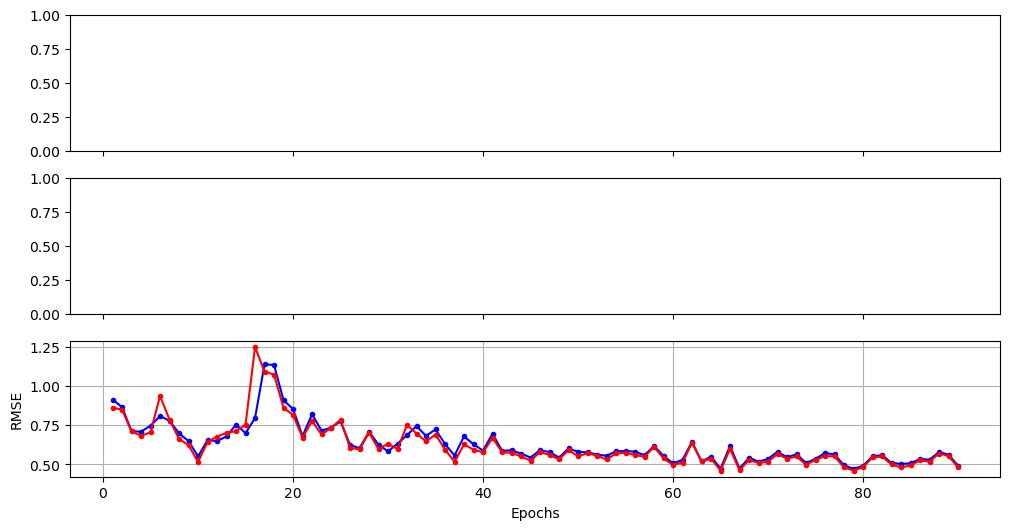

In [407]:
lepochs = list(range(1,params_train["num_epochs"] + 1))

fig, axs = plt.subplots(3, 1, figsize= (12,6), sharex=True)

# axs[0].plot(lepochs, sm_metric_history['train_vwc'], marker='.', linestyle='-', color='b', label='Training')
# axs[0].plot(lepochs, sm_metric_history['val_vwc'], marker='.', linestyle='-', color='r', label='Validation')
# #axs[0].title('Validation Loss - SM')
# axs[0].set_ylabel(metric_fn.__name__)
# axs[0].grid(True)
# axs[0].legend(bbox_to_anchor=(1,1))

# axs[1].plot(lepochs, sm_metric_history['train_actevap'], marker='.', linestyle='-', color='b', label='Training')
# axs[1].plot(lepochs, sm_metric_history['val_actevap'], marker='.', linestyle='-', color='r', label='Validation')
# #axs[0].title('Validation Loss - SM')
# axs[1].set_ylabel(metric_fn.__name__)
# axs[1].grid(True)

axs[2].plot(lepochs, [i.detach().cpu().numpy() for i in sm_loss_history['train']], marker='.', linestyle='-', color='b', label='Training')
axs[2].plot(lepochs, [i.detach().cpu().numpy() for i in sm_loss_history['val']], marker='.', linestyle='-', color='r', label='Validation')
#axs[0].title('Validation Loss - SM')
axs[2].set_xlabel('Epochs')
axs[2].set_ylabel(loss_fn.__name__)
axs[2].grid(True)

In [408]:
model.load_state_dict(torch.load(params_train["path2weights"]))

<All keys matched successfully>

In [409]:
from hython.utils import to_xr

In [410]:
torch.cuda.empty_cache()

# predict over the whole spatial domain using the model trained over the subsample
yhat = predict(Xd, Xs, model, spatial_batch_size, device=device)
yhat.shape

lat, lon, time = *train_forcings.to_dataarray().transpose("lat","lon", "time", "variable").shape[:2], Xd.shape[1]
lat*lon ,time

ret = to_xr(yhat.reshape(lat,lon,time), coords=train_targets.coords)

In [411]:
# predict over the whole spatial domain using the model trained over the subsample
yhat_valid = predict(Xd_valid, Xs, model, spatial_batch_size, device=device)

lat, lon, time = *valid_forcings.to_dataarray().transpose("lat","lon", "time", "variable").shape[:2], Xd_valid.shape[1]
lat*lon ,time


ret_valid = to_xr(yhat_valid.reshape(lat,lon,time), coords=valid_targets.coords)

In [412]:
valid_precip = valid_forcings.precip.mean(["lat","lon"]).compute()
train_precip = train_forcings.precip.mean(["lat","lon"]).compute()

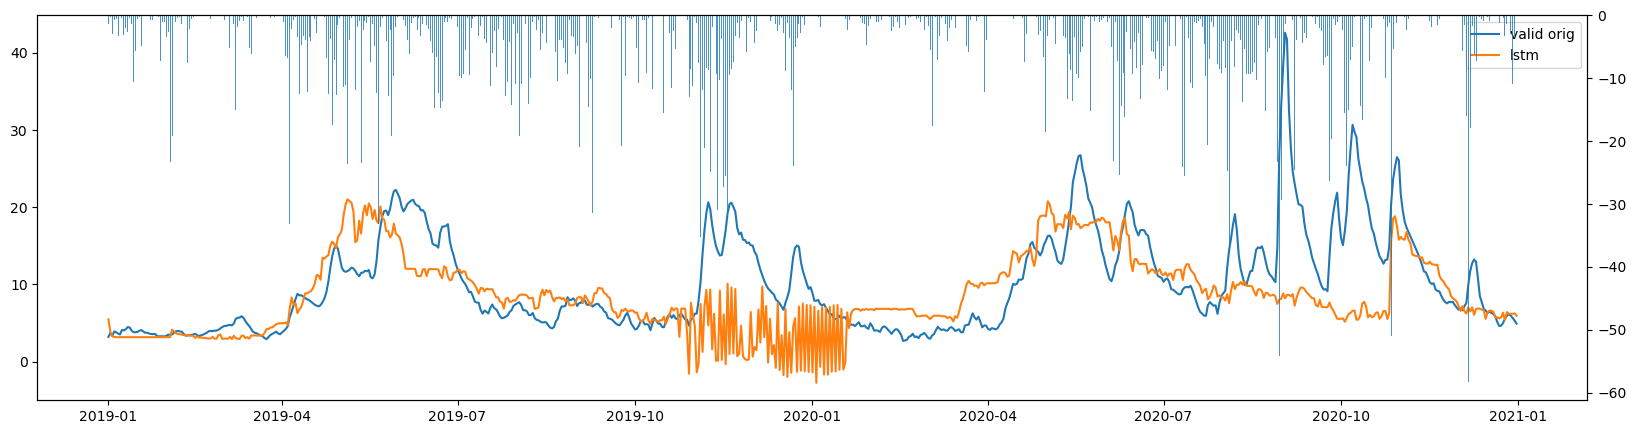

In [413]:
y_valid_plot = (Y_valid.numpy()[0,:,0])*ystd +ymean
yhat_valid_plot = ret_valid.sel(lat = outlet_lat_lon[0], lon = outlet_lat_lon[1], method="nearest").values*ystd +ymean

fig, ax = plt.subplots(1,1, figsize=(20,5))
valid_time = pd.date_range(valid_start_date,valid_end_date, freq="1D")
ax2 = ax.twinx()
ax2.bar(valid_time,-valid_precip, 0.5, alpha=0.8, fill="black")
ax.plot(valid_time,y_valid_plot, label="valid orig")
ax.plot(valid_time,yhat_valid_plot, label="lstm")
ax.legend()

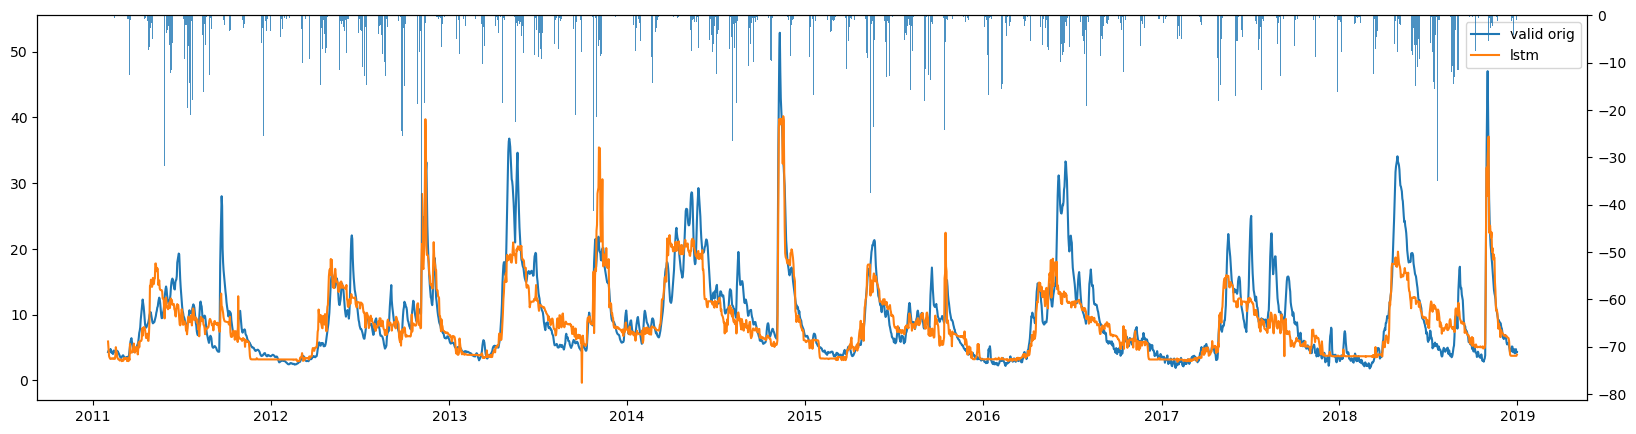

In [414]:
y_plot = (Y.numpy()[0,:,0])*ystd +ymean
yhat_plot = ret.sel(lat = outlet_lat_lon[0], lon = outlet_lat_lon[1], method="nearest").values*ystd +ymean

fig, ax = plt.subplots(1,1, figsize=(20,5))
train_time = pd.date_range(train_start_date,train_end_date, freq="1D")
ax2 = ax.twinx()
ax2.bar(train_time,-train_precip, 0.5, alpha=0.8, fill="black")
ax.plot(train_time,y_plot, label="valid orig")
ax.plot(train_time,yhat_plot, label="lstm")
ax.legend()

In [173]:
class SMEP(nn.Module):
   ...:     def __init__(self):
   ...:         super(SMEP, self).__init__()
   ...:         self.distr = nn.Linear(8,2, bias=False)
    
   ...:         self.linear = nn.Linear(2,1, bias=False)
    
   ...:     def forward(self, X):
   ...:         sm_evap = torch.stack([self.distr(time) for time in X ])#;print(sm_evap.shape)
   ...:         #q1 = torch.mean(sm_evap,0)#;print(q1.shape) n batches -> (20,2)
   ...:         #q = self.linear(q1)#;print(q.shape) smet -> (20,1)
   ...:         return sm_evap

In [174]:
class Dis(nn.Module):
    def __init__(self):
        super(Dis, self).__init__()
        self.linear = nn.Linear(2,1, bias=False)
    def forward(self, smet):
        q1 = torch.mean(smet, 0)
        #;print(q1.shape)  #n batches -> (20,2)
        q = self.linear(q1)
        #;print(q.shape) #smet -> (20,1)    
        return q
        

In [175]:
model1 = SMEP()
model2 = Dis()

In [176]:
#q, smet = model(P)

In [177]:
# # Create DataLoader
#train_dataset = TensorDataset(P, Y)

#train_loader = DataLoader(train_dataset, batch_size=3, shuffle=True)

In [178]:
import itertools

criterion = nn.MSELoss()
optimizer = optim.Adam(itertools.chain(model1.parameters(), model2.parameters()), lr=0.001)

# Training loop
num_epochs = 1000

qq = []
smsm = []

for epoch in range(num_epochs):
    model1.train()
    model2.train()
    smet_all = []
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()

        # Forward pass
        smet = model1(batch_X)
        smet_all.append(smet)
        #print(batch_y[...,[2]].shape,batch_y[...,[0,1]].shape)
        
        #loss_q = criterion(q, batch_y[[2]])
        #loss_smet = criterion(smet, batch_y[...,[0,1]])

        #loss = loss_q + loss_smet
        # Backward pass
        #loss.backward()

        # Update weights
        #optimizer.step()
    smetall = torch.cat(smet_all)

    q = model2(smetall)
    #print(q)
    #print(train_loader.dataset.tensors[1][...,[2]].shape)
    
    loss_q = criterion(q,train_loader.dataset.y[1][...,[2]])
    loss_smet = criterion(smetall, train_loader.dataset.y[1][...,[0,1]] )

    loss = loss_q + loss_smet

    loss.backward()

    optimizer.step()
    
    #print(f'Epoch {epoch + 1}/{num_epochs}, Loss: {loss.item():.4f}')

ValueError: too many values to unpack (expected 2)

In [ ]:
def predict(model1, model2, input_data, batch_size=3):
    model1.eval()
    model2.eval()
    
    # with torch.no_grad():
    #     input_tensor = torch.tensor(input_data, dtype=torch.float32)
    #     # Ensure the input tensor has the correct shape (batch_size, input_channels, height, width)
    #     # if len(input_tensor.shape) == 3:
    #     #     input_tensor = input_tensor.unsqueeze(0)
        
    #     smet = model(input_tensor)
    with torch.no_grad():

        SMET = []
        for i in range(0,input_data.shape[0], batch_size):
            
            smet = torch.Tensor(input_data[i:(i+batch_size)])
            
            SMET.append(
                model1(smet)
                )
        smetall = torch.cat(SMET)

        q = model2(smetall)

    return q.numpy(), smetall.numpy()

In [ ]:
pq, psmet = predict(model1, model2, P)

In [ ]:
plt.plot(pq)
plt.plot(Q[0], label = "true")
plt.legend()

In [ ]:
plt.plot(Y[...,[1,2]].numpy()[10], label="orig")
plt.plot(psmet[10])
plt.legend()